# The de Broglie Hypothesis and Its Experimental Verification

**Theory**
The de Broglie wavelength depends on momentum, energy, and accelerating voltage, so **unit consistency** is essential. We will work mainly in **SI units**, and we will convert to **angstroms** when that is more intuitive for atomic scales.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

h = 6.62607015e-34          # Planck constant [J s]
hbar= h /(2*np.pi)          # Reduced Planck constant [J s]
e = 1.602176634e-19         # Elementary charge [C] 
c = 2.99792458e8            # Speed of light [m/s]
m_e = 9.1093837015e-31      # Electron mass [kg]
m_p = 1.67262192369e-27     # Proton mass [kg]
m_n = 1.67492749804e-27     # Neutron mass [kg]

angstrom = 1e-10
nm = 1e-9

print("Physical constants (SI)")
print(f"h    = {h:.8e} J s")
print(f"hbar = {hbar:.8e} J s")
print(f"e    = {e:.8e} C")
print(f"c    = {c:.8e} m/s")
print(f"m_e  = {m_e:.8e} kg")
print(f"m_p  = {m_p:.8e} kg")
print(f"m_n  = {m_n:.8e} kg")

print("\nWhy units matter:")
print("If momentum is in kg m/s, then h/p gives meters.")
print("That is why all inputs must be in consistent SI units before converting "
"to Angstrom or nm.")

Physical constants (SI)
h    = 6.62607015e-34 J s
hbar = 1.05457182e-34 J s
e    = 1.60217663e-19 C
c    = 2.99792458e+08 m/s
m_e  = 9.10938370e-31 kg
m_p  = 1.67262192e-27 kg
m_n  = 1.67492750e-27 kg

Why units matter:
If momentum is in kg m/s, then h/p gives meters.
That is why all inputs must be in consistent SI units before converting to Angstrom or nm.


## Step 1 – Core de Broglie relations

**Theory**.
The de Broglie hypothesis states that every moving particle is associated with a wavelength

$$\lambda = \frac{h}{p}.$$

For a non-relativistic particle, $p = mv$, so

$$\lambda = \frac{h}{mv}.$$

In terms of kinetic energy $K$,

$$K=\frac{p^2}{2m} \Rightarrow \lambda=\frac{h}{\sqrt{2mK}}.$$

If an electron is accelerated through a potential difference $V$, then $K=eV$, and 

$$\lambda=\frac{h}{\sqrt{2m_eeV}}\approx\frac{12.27}{\sqrt{V}} \mathrm{\AA},$$

For $V$ measured in volts.


In [39]:
def de_broglie_from_p(p):
  """De Broglie wavelength from momentum p [kg m/s]."""
  return h / p

def de_broglie_from_mv(m, v):
  """Non-relativistc de Broglie wavelength from mass m [kg] and speed v [m/s]."""
  return h / (m*v)

def de_broglie_from_K(m, K):
  """Non-relativistc de Broglie wavelength from kinetic energy K [J]."""
  return h / np.sqrt(2*m*K)

def de_broglie_electron_from_voltage_nr(V):
  """Electron de Broglie wavelength accelerated by V volts (relativistic correction)."""
  V = np.asarray(V, dtype=float)
  return h / np.sqrt(2 * m_e * e * V)

def de_broglie_electron_from_voltage_rel(V):
  """Electron de Broglie wavelength accelerated by V volts (relativistic correction)."""
  V = np.asarray(V, dtype=float)
  alpha = e * V / (m_e * c**2)
  return h / np.sqrt(2 * m_e * e * V * (1 + alpha / 2))

def meters_to_angstrom(x):
  return np.asarray(x) / angstrom

print("Functions ready.")


Functions ready.


## Step 2 – First scale comparison: microscopic vs macroscopic matter waves

**Theory**
The wave nature of matter is not absent for macroscopic bodies; it is simply **too small to observe in practice**.
A good first check is to compare electrons, protons and a macroscopic object.


In [40]:
samples = [
  ("electron", m_e, 2.0e6),     # fast but non-relativistic
  ("proton",   m_p, 2.0e6),
  ("baseball (0.145 kg)", 0.145, 40.0),
]

print(f"{'Particle':<24} {'mass [kg]':>14} {'speed [m/s]':>14} {'p [kg m/s]':>16} {'lambda [m]':>16} {'lambda [Angstrom]':>14}")
print("-"*102)
for name, m, v in samples:
    p = m*v
    lam = de_broglie_from_mv(m, v)
    print(f"{name:<24} {m:>14.3e} {v:>14.3e} {p:>16.3e} {lam:>16.3e} {meters_to_angstrom(lam):>14.3e}")

print("\nInterpetation:")


Particle                      mass [kg]    speed [m/s]       p [kg m/s]       lambda [m] lambda [Angstrom]
------------------------------------------------------------------------------------------------------
electron                      9.109e-31      2.000e+06        1.822e-24        3.637e-10      3.637e+00
proton                        1.673e-27      2.000e+06        3.345e-21        1.981e-13      1.981e-03
baseball (0.145 kg)           1.450e-01      4.000e+01        5.800e+00        1.142e-34      1.142e-24

Interpetation:


## Step 3 – Consistency check among the different formulas

**Theory**.
The formulas in terms of $p, mv, K,$ and $V$ must agree when they refer to the same physical electron.

We will test the familiar classroom case $V = 100$ V, where the electron wavelength is expected to be about $1.23\AA$.


In [41]:
V0 = 100.0 # volts
K0 = e * V0
v0 = np.sqrt(2 * K0 / m_e)
p0 = m_e * v0

lam_p = de_broglie_from_p(p0)
lam_mv = de_broglie_from_mv(m_e, v0)
lam_K = de_broglie_from_K(m_e, K0)
lam_V = de_broglie_electron_from_voltage_nr(V0)

print(f"Test case: electron accelerated by V = {V0:.1f} V")
print(f"Speed (NR)      = {v0:.4e} m/s")
print(f"Momentum (NR)   = {p0:.4e} kg m/s")
print()
print(f"lambda from p   = {lam_p:.4e} m = {meters_to_angstrom(lam_p):.4f} Angstrom")
print(f"lambda from mv = {lam_mv:.4e} m = {meters_to_angstrom(lam_mv):.4f} Angstrom")
print(f"lambda from K = {lam_K:.4e} m = {meters_to_angstrom(lam_K):.4f} Angstrom")
print(f"lambda from V = {lam_V:.4e} m = {meters_to_angstrom(lam_V):.4f} Angstrom")

print("\nAll four values should agree up to numerical roundoff.")


Test case: electron accelerated by V = 100.0 V
Speed (NR)      = 5.9310e+06 m/s
Momentum (NR)   = 5.4027e-24 kg m/s

lambda from p   = 1.2264e-10 m = 1.2264 Angstrom
lambda from mv = 1.2264e-10 m = 1.2264 Angstrom
lambda from K = 1.2264e-10 m = 1.2264 Angstrom
lambda from V = 1.2264e-10 m = 1.2264 Angstrom

All four values should agree up to numerical roundoff.


## Step 4 – Wavelength vs accelerating voltage

**Theory**.
A key classroom result is that for electrons

$$\lambda\approx\frac{12.27}{\sqrt{V}}\AA.$$

This means that for modest voltages, electron wavelengths naturally fall in the **angstrom range**, which is comparable to interatomic spacings in crystals. That is why diffraction becomes observable.


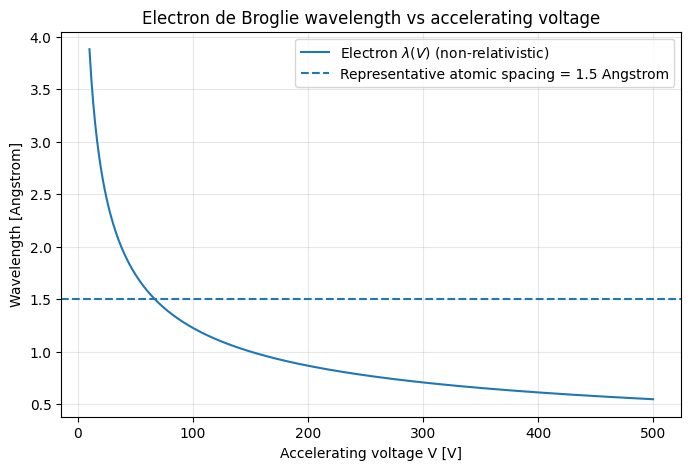

Interpretation:


In [42]:
V = np.linspace(10, 500, 600)
lam_nr = 12.27/np.sqrt(V) * angstrom
atomic_spacing = 1.5 * angstrom  # representative atomic-scale reference

plt.figure(figsize=(8,5))
plt.plot(V, meters_to_angstrom(lam_nr), label=r"Electron $\lambda(V)$ (non-relativistic)")
plt.axhline(meters_to_angstrom(atomic_spacing), linestyle="--", label="Representative atomic spacing = 1.5 Angstrom")
plt.xlabel("Accelerating voltage V [V]")
plt.ylabel("Wavelength [Angstrom]")
plt.title("Electron de Broglie wavelength vs accelerating voltage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Interpretation:")


## Step 5 – Standing waves on Bohr orbits

**Theory**.
De Broglie used the standing-wave picture to give a wave interpretation of Bohr's quantization rule. 
If a circular orbit of radius $r$ contains an integer number of wavelengths, then 

$$2\pi r=n\lambda.$$

This is equivalent to Bohr's angular momentum condition 

$$mvr=n\hbar.$$


The next figure is meant to **visualize** that idea: an integer number of matter-wave oscillations fits around the orbit circumference.


In [43]:
def plot_standing_wave_orbits(n_values=(2,3,4,5), R=1.0, amplitude=0.16):
  theta = np.linspace(0, 2*np.pi, 1200)
  
  fig, axes = plt.subplots(1, len(n_values), figsize=(3.2*len(n_values), 3.2))
  if len(n_values) == 1:
    axes = [axes]
  
  for ax, n in zip(axes, n_values):
    r_circle = np.full_like(theta, R)
    r_wave = R + amplitude * np.cos(n * theta)
    
    x_circle = r_circle * np.cos(theta)
    y_circle = r_circle * np.sin(theta)
    x_wave = r_wave * np.cos(theta)
    y_wave = r_wave * np.sin(theta)
    
    ax.plot(x_circle, y_circle, linestyle="--", linewidth=1.5, label="orbit")
    ax.plot(x_wave, y_wave, linewidth=2.0, label="standing wave")
    
    # Mark one wavelength along the circumference using an arc
    dtheta = 2*np.pi / n
    theta_arc = np.linspace(0, dtheta, 100)
    ax.plot((R+0.28)*np.cos(theta_arc), (R+0.28)*np.sin(theta_arc), linewidth=2)
    ax.text((R+0.45)*np.cos(dtheta/2), (R+0.45)*np.sin(dtheta/2),
    r"$\lambda$", ha="center", va="center", fontsize=11)

    ax.text(0, -1.45, fr"$n={n}$", ha="center", fontsize=12)
    ax.set_aspect("equal")
    ax.set_xlim(-1.55, 1.55)
    ax.set_ylim(-1.55, 1.55)
    ax.axis("off")
    
  fig.suptitle("Standing matter waves around Bohr orbits: $2\pi r = n\lambda$", y=0.98, fontsize=14)
  plt.tight_layout()
  plt.show()


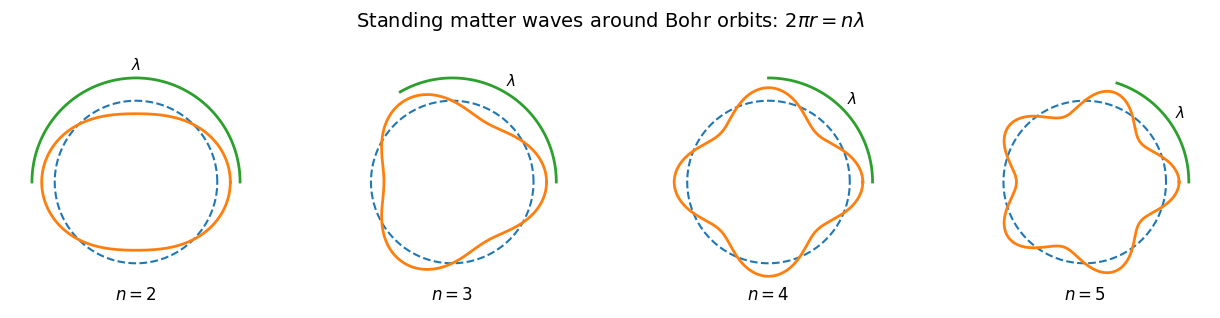

In [44]:
plot_standing_wave_orbits(n_values=(2,3,4,5), R=1.0, amplitude=0.16)

### Optional numeric check for the standing-wave condition

If the orbit radius ir $r$, then the wavelength that fits the $n$th orbit is 

$$\lambda_n = \frac{2\pi r}{n}.$$

So increasing $n$ meanos **more wavelengths fit around the circumference**, and each individual wavelength is shorter.


In [45]:
r_demo = 1.0  # arbitrary units for visualization 
print(f"{'n':>4} {'lambda_n = 2 pi r/ n':>20}")
print("-"*26)
for n in [1,2,3,4,5]:
  lam_n = 2*np.pi*r_demo / n
  print(f"{n:>4d} {lam_n:>20.5f}")
  
print("\nThis table is purely geometric: "
  "it shows how an integer number of "
  "wavelengths fits around")
print("a fixed circumference")  


   n lambda_n = 2 pi r/ n
--------------------------
   1              6.28319
   2              3.14159
   3              2.09440
   4              1.57080
   5              1.25664

This table is purely geometric: it shows how an integer number of wavelengths fits around
a fixed circumference


## Step 6 – Virtual experiment 1: simplified Davisson-Germer geometry

**Theory**.
Electron diffraction provided direct support for de Broglie's hypothesis.
In a simplified crystal-diffraction model, we use a first-order Bragg condition

$$\lambda = 2d \sin \theta_B,$$
and if the measured scattering angles is $\phi=2\theta_B,$ then 

$$\lambda=2d\sin(\phi/2).$$
In this notebook we use a **toy effective spacing** $d_{\text{eff}}$ to make the trends clear.
The goal is not to reproduce every historical detail, but to show how **de Broglie wavelength + crystal spacing + measured angle** fit together.


Using d_eff = 1.50 Angstrom

   V [V] lambda [Armstrong]   phi_pred [deg]
------------------------------------------
    40.0         1.9391            80.54
    50.0         1.7344            70.64
    60.0         1.5833            63.71
    80.0         1.3712            54.40
   100.0         1.2264            48.26
   150.0         1.0014            39.00
   200.0         0.8672            33.60
   250.0         0.7757            29.97


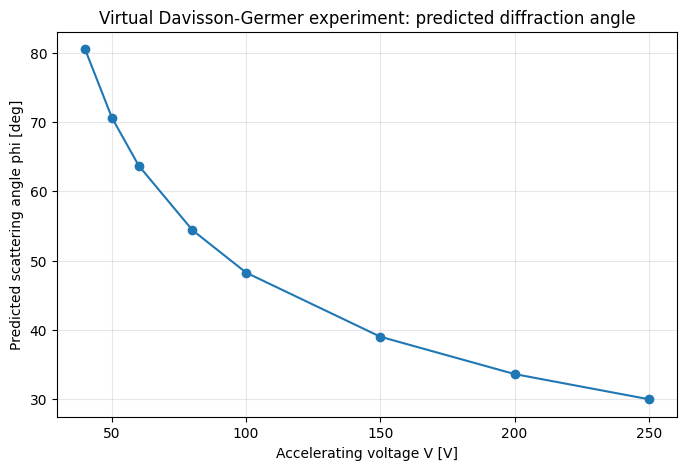

Interpretation:


In [46]:
d_eff = 1.5 * angstrom   # effective crystal spacing for a didactic toy model

V_scan = np.array([40, 50, 60, 80, 100, 150, 200, 250], dtype=float)
lam_scan = de_broglie_electron_from_voltage_nr(V_scan)

arg = lam_scan / (2*d_eff)
valid = arg <= 1.0

phi_deg = np.full_like(V_scan, np.nan)
phi_deg[valid] = 2*np.degrees(np.arcsin(arg[valid]))

print(f"Using d_eff = {meters_to_angstrom(d_eff):.2f} Angstrom")
print()
print(f"{'V [V]':>8} {'lambda [Armstrong]':>14} {'phi_pred [deg]':>16}")
print("-"*42)
for V_i, lam_i, phi_i in zip(V_scan, lam_scan, phi_deg):
  phi_text = f"{phi_i:0.2f}" if np.isfinite(phi_i) else "no 1st-order peak"
  print(f"{V_i:>8.1f} {meters_to_angstrom(lam_i):>14.4f} {phi_text:>16}")

plt.figure(figsize=(8,5))
plt.plot(V_scan[valid], phi_deg[valid], marker="o")
plt.xlabel("Accelerating voltage V [V]")
plt.ylabel("Predicted scattering angle phi [deg]")
plt.title("Virtual Davisson-Germer experiment: predicted diffraction angle")
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")


## Step 7 – Angular scan: intensity vs angle

**Theory**.
A real diffraction experiment does not measure only a formula; it scans the detector angle and records intensity. We can mimic that with a simple **Gaussian peak** centered at the predicted angle $\phi_0(V)$.

This makes the experiment much easier to *see*:

- change the voltage,

- the de Broglie wavelength changes,

- the diffraction angle changes,

- and the intensity peak moves.


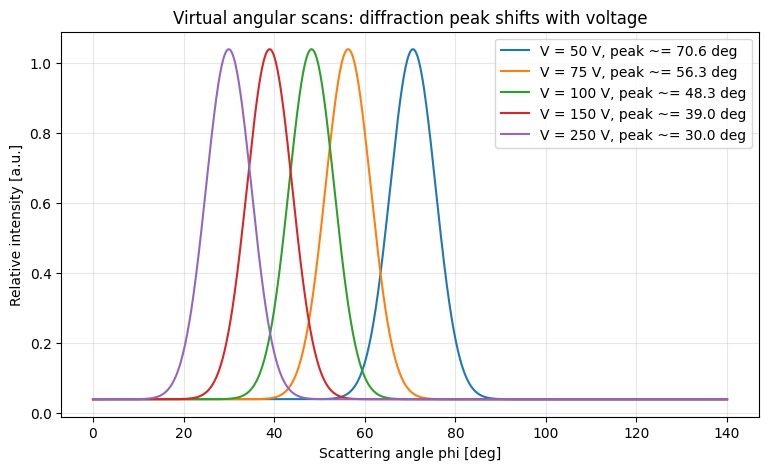

In [47]:
def toy_intensity(phi_deg_axis, phi0_deg, sigma_deg=5.0, amplitude=1.0, background=0.04):
  return background + amplitude * np.exp(-0.5*((phi_deg_axis - phi0_deg)/sigma_deg)**2)

phi_axis = np.linspace(0, 140, 1200)
voltages_for_scans = np.array([50, 75, 100, 150, 250], dtype=float)
lam_for_scans = de_broglie_electron_from_voltage_nr(voltages_for_scans) 
phi0_scans = 2*np.degrees(np.arcsin(lam_for_scans/(2*d_eff)))

plt.figure(figsize=(9,5))
for V_i, phi0_i in zip(voltages_for_scans, phi0_scans):
  I = toy_intensity(phi_axis, phi0_i, sigma_deg=5.0)
  plt.plot(phi_axis, I, label=f"V = {V_i:.0f} V, peak ~= {phi0_i:.1f} deg")
  
plt.xlabel("Scattering angle phi [deg]")
plt.ylabel("Relative intensity [a.u.]")
plt.title("Virtual angular scans: diffraction peak shifts with voltage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


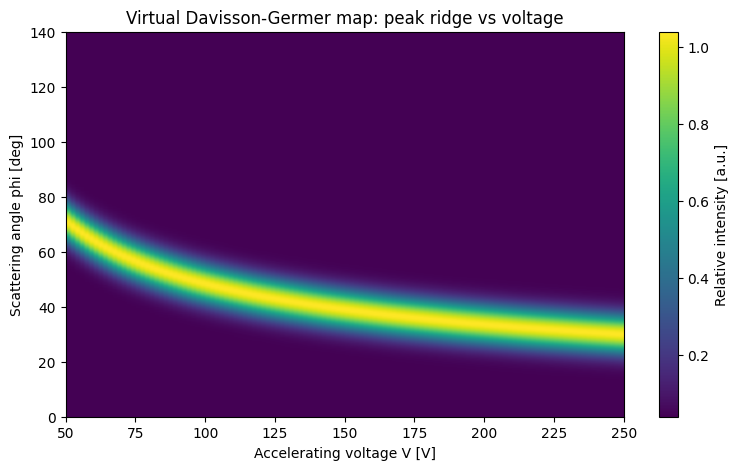

This map makes the experimental trend very clear: the bright ridge
moves because the de Broglie wavelength depends on V.


In [48]:
# 2D map: intensity as a function of voltage and angle
V_map = np.linspace(50, 250, 120)
phi_map = np.linspace(0, 140, 400)

lam_map = de_broglie_electron_from_voltage_nr(V_map)
phi0_map = 2*np.degrees(np.arcsin(lam_map/(2*d_eff)))

I_map = np.zeros((len(phi_map), len(V_map)))
for j, phi0 in enumerate(phi0_map):
  I_map[:, j] = toy_intensity(phi_map, phi0, sigma_deg=5.0)
  
plt.figure(figsize=(9,5))
plt.imshow(I_map, origin="lower", aspect="auto", extent=[V_map.min(), 
V_map.max(), phi_map.min(), phi_map.max()])
plt.colorbar(label="Relative intensity [a.u.]")
plt.xlabel("Accelerating voltage V [V]")
plt.ylabel("Scattering angle phi [deg]")
plt.title("Virtual Davisson-Germer map: peak ridge vs voltage")
plt.show()

print("This map makes the experimental trend very clear: the bright ridge") 
print("moves because the de Broglie wavelength depends on V.")


## Step 8 – Straight-line verification form

**Theory**.
A very useful experimental habit is to rewrite a model in a linear form.

From 

$$\lambda=\frac{12.27}{\sqrt{V}}\AA \,\,\ \text{and} \,\,\ \lambda=2d\sin(\phi/2),$$

we obtain

$$\sin(\phi/2)\propto\frac{1}{\sqrt{V}}.$$

So if the model is correct, a plot of

$$y=\sin(\phi/2) \,\,\ \text{vs} \,\,\ x=\frac{1}{\sqrt{V}}$$

should be approximately linear.


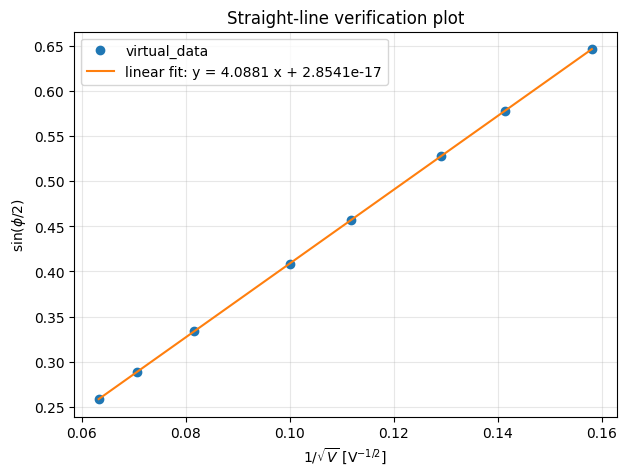

Slope     = 4.088087
Intercept = 2.854126e-17

The near-linearity shows how the diffraction-angle data are  consistent with the de Broglie prediction.


In [49]:
x = 1 / np.sqrt(V_scan[valid])
y = np.sin(np.radians(phi_deg[valid] / 2))

coef = np.polyfit(x, y, 1)
y_fit = np.polyval(coef, x)

plt.figure(figsize=(7,5))
plt.plot(x, y, "o", label="virtual_data")
plt.plot(x, y_fit, "-", label=f"linear fit: y = {coef[0]:.4f} x + {coef[1]:.4e}")
plt.xlabel(r"$1/\sqrt{V}$ [V$^{-1/2}$]")
plt.ylabel(r"$\sin(\phi/2)$")
plt.title("Straight-line verification plot")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Slope     = {coef[0]:.6f}")
print(f"Intercept = {coef[1]:.6e}")

print("\nThe near-linearity shows how the diffraction-angle data are  consistent with the de Broglie prediction.")


## Step 9 – When does relativity matter?

**Theory**.
For electrons accelerated through a voltage $V$, the non-relativistic formula works very well at low voltages, but eventually a relativistic correction is needed.
A convenient expression is

$$\lambda_{\text{rel}}=\frac{h}{\sqrt{2m_e eV \Big(1+\frac{eV}{2m_ec^2}\Big)}}.$$
Since $m_ec^2/e\approx 511 kV$, the correction is negligible for voltages much smaller than that scale.


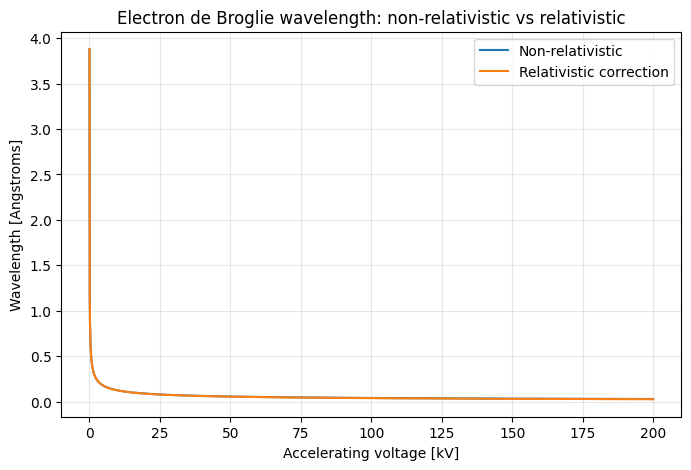

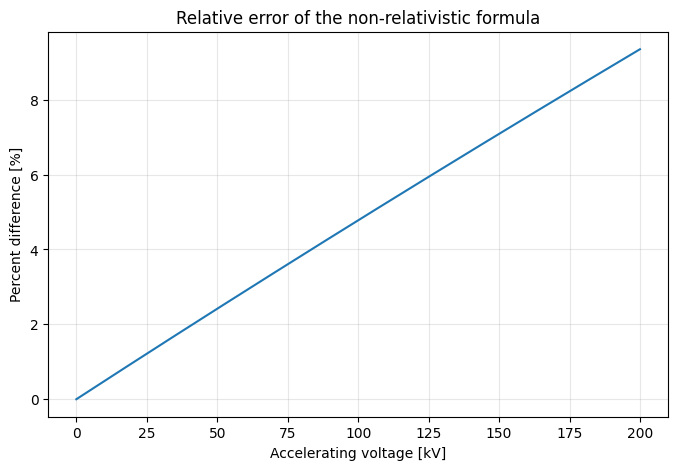

V =    100 V -> percent_difference ~= 0.004892%
V =   1000 V -> percent_difference ~=  0.04891%
V =  10000 V -> percent_difference ~=    0.488%
V =  50000 V -> percent_difference ~=    2.417%
V = 100000 V -> percent_difference ~=    4.778%


In [51]:
V_rel = np.linspace(10, 2.0e5, 2000)   # 10 V to 200 kV
lam_nr_relplot = de_broglie_electron_from_voltage_nr(V_rel)
lam_rel = h / (np.sqrt(2 * m_e * e * V_rel * (1 + (e * V_rel)/(2 * m_e * c**2))))
percent_diff = 100 * np.abs(lam_rel - lam_nr_relplot) / lam_rel

plt.figure(figsize=(8,5))
plt.plot(V_rel/1000, meters_to_angstrom(lam_nr_relplot), label="Non-relativistic")
plt.plot(V_rel/1000, meters_to_angstrom(lam_rel), label="Relativistic correction")
plt.xlabel("Accelerating voltage [kV]")
plt.ylabel("Wavelength [Angstroms]")
plt.title("Electron de Broglie wavelength: non-relativistic vs relativistic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(V_rel/1000, percent_diff)
plt.xlabel("Accelerating voltage [kV]")
plt.ylabel("Percent difference [%]")
plt.title("Relative error of the non-relativistic formula")
plt.grid(True, alpha=0.3)
plt.show()

for V_test in [100, 1000, 10000, 50000, 100000]:
  diff = 100 * abs(
    de_broglie_electron_from_voltage_rel(V_test) - de_broglie_electron_from_voltage_nr(V_test)) / de_broglie_electron_from_voltage_rel(V_test)
  print(f"V = {V_test:>6.0f} V -> percent_difference ~= {diff:8.4}%")  
